# Recitation 1 — Python for Machine Learning

**Goal:** get everyone from “I can open a notebook” to “I can manipulate data and run a tiny ML workflow.”

# 0. Quick setup in VS Code

There are two common ways to prepare a Python environment for this course:

### Option A — Regular Python + `pip`
Simple and sufficient for most students.

### Option B — Conda
Useful if you already use Anaconda / Miniconda, or if you want stronger environment management.

You only need **one** of these two setups.

# Option A — Regular Python + `pip`

## Step 1 — Install Python

Download and install a recent **Python 3** release from:

**https://www.python.org/downloads/**

On Windows, it is helpful to check:

```text
Add Python to PATH
```

during installation.

## Step 2 — Open the notebook in VS Code

Install the **Python** and **Jupyter** extensions in VS Code.

Open the course folder and the `.ipynb` file.

Then click **Select Kernel** in the upper-right corner and choose your installed **Python 3** interpreter.

You can also use:

```text
Ctrl/Cmd + Shift + P
→ Python: Select Interpreter
```

## Step 3 — Install the packages

Open:

**Terminal → New Terminal**

and run:

```bash
pip install numpy pandas matplotlib scikit-learn
```

You can also install them directly inside the notebook:

In [ ]:
# Run this only if the packages are not installed yet:
%pip install numpy pandas matplotlib scikit-learn

# Option B — Conda

If you already use **Anaconda** or **Miniconda**, you can create a separate course environment.

Open a terminal and run:

```bash
conda create -n ml python=3.12
conda activate ml
```

Then install the packages:

```bash
pip install numpy pandas matplotlib scikit-learn
```

You can also use Conda for the packages:

```bash
conda install numpy pandas matplotlib scikit-learn
```

For this course, either installation method is fine.

## Select the Conda environment in VS Code

Open the notebook and click **Select Kernel**.

Choose the environment named:

```text
ml
```

or use:

```text
Ctrl/Cmd + Shift + P
→ Python: Select Interpreter
→ ml
```

## Quick check

If this cell runs, your environment is ready.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 1.26.4
pandas: 3.0.2
scikit-learn: 1.8.0


# 1. Python syntax essentials

We only cover syntax that will immediately appear in data science / ML code.

## 1.1 Variables and basic types

In [2]:
epochs = 20
learning_rate = 0.001
model_name = "logistic regression"
use_gpu = False

print(epochs, type(epochs))
print(learning_rate, type(learning_rate))
print(model_name, type(model_name))
print(use_gpu, type(use_gpu))

20 <class 'int'>
0.001 <class 'float'>
logistic regression <class 'str'>
False <class 'bool'>


### `=` vs. `==`

- `=` assigns a value
- `==` checks whether two values are equal

In [3]:
x = 10

print(x == 10)
print(x == 5)

True
False


## 1.2 Lists and indexing

In [5]:
losses = [0.90, 0.61, 0.43, 0.32, 0.27]

# Indexing:
# sequence[index]

# Slicing:
# sequence[start:end:stride]
# start  : first index to include
# end    : stopping index, not included
# stride : step size

print("first:", losses[0])          # first element
print("last:", losses[-1])          # last element
print("first three:", losses[:3])   # indices 0, 1, 2
print("every other value:", losses[::2])  # indices 0, 2, 4

first: 0.9
last: 0.27
first three: [0.9, 0.61, 0.43]
every other value: [0.9, 0.43, 0.27]


## 1.3 Dictionaries

In [8]:
# Dictionary:
# dictionary = {
#     "key1": value1,
#     "key2": value2,
# }

# Access a value:
# dictionary["key"]

# Update an existing key:
# dictionary["key"] = new_value

# Add a new key-value pair:
# dictionary["new_key"] = value

config = {
    "batch_size": 32,
    "epochs": 20,
    "optimizer": "Adam",
}

print(config["optimizer"])        # access value by key

config["epochs"] = 30             # update existing value
config["weight_decay"] = 1e-4     # add a new key-value pair

print(config)

Adam
{'batch_size': 32, 'epochs': 30, 'optimizer': 'Adam', 'weight_decay': 0.0001}


## 1.4 `if` statements

In [10]:
# Conditional statement:
#
# if condition1:
#     code block 1
# elif condition2:
#     code block 2
# else:
#     code block 3
#
# Notes:
# - Conditions evaluate to True or False
# - Use indentation to define each code block
# - elif and else are optional

accuracy = 0.87

if accuracy >= 0.90:
    print("Excellent")
elif accuracy >= 0.80:
    print("Good")
else:
    print("Needs improvement")

Good


## 1.5 `for` loops

In [13]:
# For loop:
#
# for variable in iterable:
#     code block
#
# Common iterables:
# - range(...)
# - list
# - string
# - dictionary
# - NumPy array / pandas objects


# 1. Loop over a range
# range(start, stop, step)
# stop is NOT included

for epoch in range(5):
    print("epoch:", epoch)


epoch: 0
epoch: 1
epoch: 2
epoch: 3
epoch: 4


In [14]:
# 2. Loop over values in a list

losses = [0.90, 0.61, 0.43, 0.32]

for loss in losses:
    print("loss:", loss)

loss: 0.9
loss: 0.61
loss: 0.43
loss: 0.32


In [15]:
# 3. Get both index and value with enumerate()
# enumerate(iterable) -> (index, value)

for i, loss in enumerate(losses):
    print("index:", i, "loss:", loss)

index: 0 loss: 0.9
index: 1 loss: 0.61
index: 2 loss: 0.43
index: 3 loss: 0.32


In [16]:
# 4. Loop over two iterables together with zip()
# zip(iterable1, iterable2) -> pairs corresponding elements

epochs = [1, 2, 3, 4]
losses = [0.90, 0.61, 0.43, 0.32]

for epoch, loss in zip(epochs, losses):
    print("epoch:", epoch, "loss:", loss)

epoch: 1 loss: 0.9
epoch: 2 loss: 0.61
epoch: 3 loss: 0.43
epoch: 4 loss: 0.32


In [17]:
# 5. Loop over a dictionary
# dictionary.items() -> (key, value) pairs

config = {
    "batch_size": 32,
    "epochs": 20,
    "optimizer": "Adam",
}

for key, value in config.items():
    print(key, ":", value)

batch_size : 32
epochs : 20
optimizer : Adam


## 1.6 Functions

In [20]:
# Function:
#
# def function_name(parameter1, parameter2, ...):
#     code block
#     return result
#
# - def: define a function
# - parameters: inputs to the function
# - return: send the result back to the caller


def mse(y_true, y_pred):
    error = y_true - y_pred
    return np.mean(error ** 2)


y_true = np.array([3.0, 4.0, 5.0])
y_pred = np.array([2.5, 4.2, 4.6])

print(mse(y_true, y_pred))

0.15000000000000013


## 1.7 List comprehensions

In [21]:
# List comprehension:
#
# [expression for variable in iterable]
#
# Equivalent to:
#
# result = []
# for variable in iterable:
#     result.append(expression)


numbers = [1, 2, 3, 4, 5]

squares = [x**2 for x in numbers]

print(squares)

[1, 4, 9, 16, 25]


In [22]:
# List comprehension with a condition:
#
# [expression for variable in iterable if condition]

even_squares = [x**2 for x in numbers if x % 2 == 0]

print(even_squares)

[4, 16]


# 2. NumPy: arrays for numerical ML

## 2.1 Python list vs. NumPy array

In [ ]:
# NumPy array:
#
# np.array(data)
#
# Convert a Python sequence (e.g., list) into a NumPy array.
#
# Useful attributes:
# array.shape  -> dimensions of the array
# array.dtype  -> data type stored in the array


python_list = [1, 2, 3, 4]

x = np.array(python_list)

print("Python list:", python_list)
print("NumPy array:", x)

print("type:", type(x))     # numpy.ndarray
print("shape:", x.shape)    # (4,) -> 1D array with 4 elements
print("dtype:", x.dtype)    # e.g., int32

Python list: [1, 2, 3, 4]
NumPy array: [1 2 3 4]
type: <class 'numpy.ndarray'>
shape: (4,)
dtype: int32


In [26]:
# Python list:
# - general-purpose container
# - can contain mixed data types

# NumPy array:
# - designed for numerical computation
# - usually contains one data type
# - supports vectorized operations

python_list = [1, 2, 3, 4]
x = np.array(python_list)

python_list = [1, 2.5, "hello", True]

print(python_list)

print(python_list * 2)  # repeats the list
print(x * 2)            # multiplies each element by 2

[1, 2.5, 'hello', True]
[1, 2.5, 'hello', True, 1, 2.5, 'hello', True]
[2 4 6 8]


## 2.2 A feature matrix

In [27]:
X = np.array([
    [1.2,  7.0,  0.5],
    [2.4,  6.5,  0.7],
    [3.1,  8.2,  0.9],
    [4.8,  9.0,  1.3],
])

print("X shape:", X.shape)

X shape: (4, 3)


For ML, we usually use:

- **rows = samples**
- **columns = features**

So `X.shape == (4, 3)` means:

- 4 samples
- 3 features

## 2.3 Indexing a matrix

In [29]:
X = np.array([
    [1.2,  7.0,  0.5],
    [2.4,  6.5,  0.7],
    [3.1,  8.2,  0.9],
    [4.8,  9.0,  1.3],
])

print("first sample:", X[0])
print("second feature:", X[:, 1])
print("first two rows:\n", X[:2])

first sample: [1.2 7.  0.5]
second feature: [7.  6.5 8.2 9. ]
first two rows:
 [[1.2 7.  0.5]
 [2.4 6.5 0.7]]


## 2.4 Vectorized arithmetic

In [30]:
x = np.array([1, 2, 3, 4])

print("x + 5  =", x + 5)
print("x * 2  =", x * 2)
print("x ** 2 =", x ** 2)

x + 5  = [6 7 8 9]
x * 2  = [2 4 6 8]
x ** 2 = [ 1  4  9 16]


## 2.5 Aggregation and `axis`

In [32]:
# Aggregation with axis:
#
# X.mean()        -> mean of ALL elements
#
# X.mean(axis=0)  -> compute down the rows
#                    result: one mean for each column / feature
#
# X.mean(axis=1)  -> compute across the columns
#                    result: one mean for each row / sample


print("overall mean:", X.mean())

print("mean of each column:", X.mean(axis=0))

print("mean of each row:", X.mean(axis=1))

overall mean: 3.7999999999999994
mean of each column: [2.875 7.675 0.85 ]
mean of each row: [2.9        3.2        4.06666667 5.03333333]


### Useful mental model

For a matrix shaped `(samples, features)`:

- `axis=0` → collapse rows → one value per feature
- `axis=1` → collapse columns → one value per sample

## 2.6 Broadcasting

In [33]:
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)

X_standardized = (X - feature_mean) / feature_std

print("feature means:", feature_mean)
print("feature std:", feature_std)
print("\nstandardized X:\n", np.round(X_standardized, 2))

feature means: [2.875 7.675 0.85 ]
feature std: [1.30264155 0.98329802 0.29580399]

standardized X:
 [[-1.29 -0.69 -1.18]
 [-0.36 -1.19 -0.51]
 [ 0.17  0.53  0.17]
 [ 1.48  1.35  1.52]]


# 3. Why vectorization matters

We compute

\[
y = 3x^2 + 2x + 1
\]

for many values.

In [37]:
import numpy as np
# --------------------------------------------------
# NumPy random numbers
# --------------------------------------------------

# np.random
# is NumPy's module for generating random numbers.

# Common examples:
# np.random.random(size)   -> random values between 0 and 1
# np.random.randint(...)   -> random integers
# np.random.normal(...)    -> samples from a normal distribution


# Generate 5 random numbers between 0 and 1
print(np.random.random(5))

# Generate 5 random integers from 0 to 9
print(np.random.randint(0, 10, 5))

# Generate 5 samples from a standard normal distribution
print(np.random.normal(0, 1, 5))

[0.73864203 0.61767639 0.49914322 0.28016996 0.41125183]
[9 0 0 9 3]
[ 1.09781549  0.81814154 -1.31315257  2.58891518 -1.2956019 ]


In [38]:
import time
import numpy as np


# --------------------------------------------------
# Generate random input data
# --------------------------------------------------

# np.random.default_rng(seed)
# creates a random number generator
# seed=42 makes the random numbers reproducible
random_generator = np.random.default_rng(42)

# Generate 500,000 random numbers between 0 and 1
x = random_generator.random(500000)


# --------------------------------------------------
# Method 1: Python for loop
# --------------------------------------------------

# time.perf_counter()
# returns a high-resolution timer
# useful for measuring execution time
start = time.perf_counter()

y_loop = []

for value in x:
    y_loop.append(3 * value**2 + 2 * value + 1)

loop_time = time.perf_counter() - start


# --------------------------------------------------
# Method 2: NumPy vectorization
# --------------------------------------------------

# Vectorization:
# perform an operation on the entire array
# instead of explicitly looping over each element

start = time.perf_counter()

y_numpy = 3 * x**2 + 2 * x + 1

numpy_time = time.perf_counter() - start


# --------------------------------------------------
# Compare execution time
# --------------------------------------------------

print(f"Python loop: {loop_time:.4f} s")
print(f"NumPy:       {numpy_time:.4f} s")
print(f"Speedup:     {loop_time / numpy_time:.1f}x")


# --------------------------------------------------
# Check whether both methods give the same result
# --------------------------------------------------

# np.allclose(a, b)
# checks whether two arrays are approximately equal
# useful for comparing floating-point results

print("Same result:", np.allclose(y_loop, y_numpy))

Python loop: 0.1304 s
NumPy:       0.0037 s
Speedup:     35.2x
Same result: True


# 4. A small dataset for the rest of the demo

We will now create a toy dataset that looks like measurement data.

Each sample has:

- temperature
- vibration
- current

Target:

- `0` = normal
- `1` = fault

In [ ]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 300

temperature = rng.normal(72, 7, n)
vibration = np.abs(rng.normal(1.8, 0.7, n))
current = rng.normal(12, 2.0, n)

score = (
    0.12 * (temperature - 72)
    + 1.0 * (vibration - 1.8)
    + 0.15 * (current - 12)
    + rng.normal(0, 0.7, n)
)

# Create binary class labels from the score:
#
# score > 1.0
# returns a Boolean array:
# False, True, False, True, ...
#
# .astype(int)
# converts:
# False -> 0
# True  -> 1
fault = (score > 1.0).astype(int)

print("samples:", n)
print("fault rate:", fault.mean())


samples: 300
fault rate: 0.19333333333333333


# 5. Matplotlib: look at the data

## 5.1 Histogram

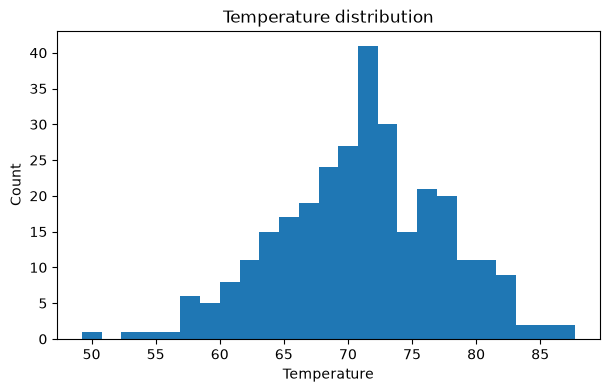

In [ ]:
# plt.figure(figsize=(width, height))
# creates a new figure.
#
# figsize controls the figure size in inches:
# width = 7
# height = 4
plt.figure(figsize=(7, 4))
# plt.hist(data, bins=...)
# plots a histogram to show the distribution of data.
#
# data:
#   values to be plotted
#
# bins:
#   number of intervals used to group the data
plt.hist(temperature, bins=25)
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Temperature distribution")
plt.show()

## 5.2 Scatter plot

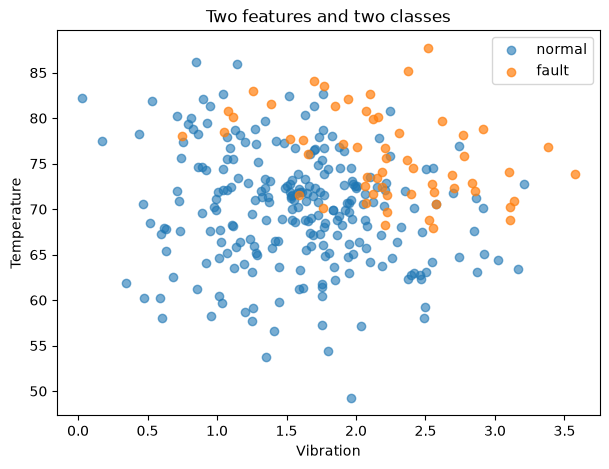

In [ ]:
plt.figure(figsize=(7, 5))

# plt.scatter(x, y, ...)
# creates a scatter plot.
#
# x:
#   values on the horizontal axis
#
# y:
#   values on the vertical axis
#
# alpha:
#   transparency of the points
#   1.0 = fully opaque
#   smaller value = more transparent
#
# label:
#   name used in the legend

plt.scatter(
    vibration[fault == 0],
    temperature[fault == 0],
    alpha=0.6,
    label="normal",
)

plt.scatter(
    vibration[fault == 1],
    temperature[fault == 1],
    alpha=0.7,
    label="fault",
)

plt.xlabel("Vibration")
plt.ylabel("Temperature")
plt.title("Two features and two classes")
# plt.legend()
# displays a legend using the labels defined in the plot
plt.legend()
plt.show()

# 6. pandas + CSV

NumPy is great for arrays.

pandas is especially convenient for **tables with named columns**.

In [50]:
# pd.DataFrame(...)
# creates a table with rows and named columns.
#
# Each dictionary key becomes a column name,
# and each value provides the data for that column.

df = pd.DataFrame({
    "temperature": [72, 75, 81, 68, 77],
    "vibration":   [1.2, 1.8, 2.6, 1.0, 2.1],
    "current":     [11.5, 12.1, 14.2, 10.9, 13.0],
    "fault":       [0, 0, 1, 0, 1],
})
print(df)


   temperature  vibration  current  fault
0           72        1.2     11.5      0
1           75        1.8     12.1      0
2           81        2.6     14.2      1
3           68        1.0     10.9      0
4           77        2.1     13.0      1


In [53]:
# Row labels
print("index:")
print(df.index)

# Column labels
print("\ncolumns:")
print(df.columns)
# Select multiple columns

index:
RangeIndex(start=0, stop=5, step=1)

columns:
Index(['temperature', 'vibration', 'current', 'fault'], dtype='str')


In [54]:
print(df[["temperature", "vibration"]])

   temperature  vibration
0           72        1.2
1           75        1.8
2           81        2.6
3           68        1.0
4           77        2.1


In [57]:
# df.loc[row, column]
# selects data using row labels and column names

print(df.loc[2, "vibration"])
# np.nan represents a missing numerical value

df.loc[2, "vibration"] = np.nan

print(df)

2.6
   temperature  vibration  current  fault
0           72        1.2     11.5      0
1           75        1.8     12.1      0
2           81        NaN     14.2      1
3           68        1.0     10.9      0
4           77        2.1     13.0      1


In [58]:
# Check missing values
print(df.isna())
# Count missing values in each column
print(df.isna().sum())

   temperature  vibration  current  fault
0        False      False    False  False
1        False      False    False  False
2        False       True    False  False
3        False      False    False  False
4        False      False    False  False
temperature    0
vibration      1
current        0
fault          0
dtype: int64


## 6.1 Save and reload a CSV

In [ ]:
csv_path = "machine_demo.csv"

df.to_csv(csv_path, index=False)

df = pd.read_csv(csv_path)

# df.head(n)
# displays the first n rows of a DataFrame.
#
# If n is omitted, pandas shows the first 5 rows by default.
df.head()

,temperature,vibration,current,fault
0,72,1.2,11.5,0
1,75,1.8,12.1,0
2,81,NaN,14.2,1
3,68,1.0,10.9,0
4,77,2.1,13.0,1


## 6.2 Filter rows

In [64]:
df[df["temperature"] > 80].head()

,temperature,vibration,current,fault
2,81,NaN,14.2,1


## 6.3 Multiple conditions

In [65]:
df[
    (df["temperature"] > 75)
    & (df["vibration"] > 2.0)
].head()

,temperature,vibration,current,fault
4,77,2.1,13.0,1


## 6.6 Group and summarize

In [ ]:
# Group rows by the values in the "fault" column
grouped = df.groupby("fault")

# Select the columns we want to summarize
selected = grouped[["temperature", "vibration", "current"]]

# Compute the mean of each column within each group
summary = selected.mean()

# Round the displayed values to 2 decimal places
summary = summary.round(2)

print(summary)

df.groupby("fault")[["temperature", "vibration", "current"]].mean().round(2)

       temperature  vibration  current
fault                                 
0            71.67       1.33     11.5
1            79.00       2.10     13.6


,temperature,vibration,current
fault,,,
0,71.67,1.33,11.5
1,79.00,2.10,13.6


## 6.7 Feature engineering

In [69]:
df["stress_index"] = df["vibration"] * df["current"]

df.head()

,temperature,vibration,current,fault,stress_index
0,72,1.2,11.5,0,13.80
1,75,1.8,12.1,0,21.78
2,81,NaN,14.2,1,NaN
3,68,1.0,10.9,0,10.90
4,77,2.1,13.0,1,27.30


# 7. First scikit-learn workflow

The purpose is to see the standard workflow:

> **split → preprocess → fit → predict → evaluate**


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## 7.1 Prepare `X` and `y`

In [71]:
features = [
    "temperature",
    "vibration",
    "current",
    "stress_index",
]

X = df[features]
y = df["fault"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 4)
y shape: (5,)


## 7.2 Train/test split

In [85]:
# train_test_split(...)
# splits the dataset into training and testing sets.
#
# X -> input features
# y -> target labels
#
# test_size=0.25
# -> 25% of the data goes to the test set
# -> 75% goes to the training set
#
# random_state=42
# -> fixes the random split so the result is reproducible
#
# stratify=y
# keeps the proportion of each class approximately the same in the training set and the test set

X = df[features].to_numpy()
y = df["fault"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape)
print("test: ", X_test.shape)

train: (3, 4)
test:  (2, 4)


## 7.3 Build a pipeline

In [86]:
# make_pipeline(...)
# combines several preprocessing/modeling steps into one workflow.
#
# The data will pass through these steps in order:
# 1. SimpleImputer
# 2. StandardScaler
# 3. LogisticRegression

model = make_pipeline(
    # SimpleImputer(strategy="median")
    # fills missing values (NaN) using the median
    # of each feature/column
    SimpleImputer(strategy="median"),

    # StandardScaler()
    # standardizes each feature using:
    #
    # x_scaled = (x - mean) / standard_deviation
    #
    # After scaling, each feature is approximately:
    # mean = 0
    # standard deviation = 1
    StandardScaler(),

    # LogisticRegression(max_iter=1000)
    # creates a logistic regression classifier.
    #
    # max_iter:
    # maximum number of optimization iterations
    LogisticRegression(max_iter=1000),
)

## 7.4 Fit

In [87]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite

## 7.5 Predict

In [88]:
y_pred = model.predict(X_test)

print(f"X_test: {X_test}, \ny_test: {y_test}")
print(f"y_pred: {y_pred}")

X_test: [[68.   1.  10.9 10.9]
 [81.   nan 14.2  nan]], 
y_test: [0 1]
y_pred: [0 1]


## 7.6 Evaluate

Test accuracy: 1.000


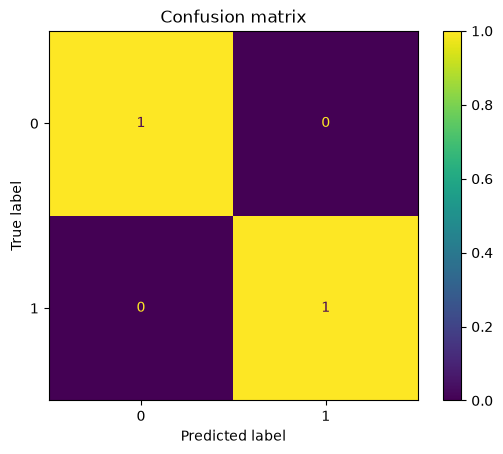

In [84]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion matrix")
plt.show()